# Homework Submission - Stage 10b: Time Series & Classification

This completed notebook uses the seeded synthetic time series and evaluates both forecasting and direction-classification baselines.


In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

Matplotlib is building the font cache; this may take a moment.


## Option A: Use Your Project Data (Recommended)
Load your data here (ensure a DateTime index for time series).

In [3]:
# The self-contained synthetic generator below is used for this submission.
# It provides a DateTime index, regimes, and jumps without an external API.


## Option B: Synthetic Generator (Use if you don't have data ready)

In [4]:
# Synthetic series with regimes & jumps
n=500
dates=pd.bdate_range('2021-01-01', periods=n)
mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)
jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
rets = eps + jumps
price = 100*np.exp(np.cumsum(rets))
df = pd.DataFrame({'price':price}, index=dates)
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])
df.head()

,price,ret,log_ret
2021-01-01,101.735412,0.000000,0.000000
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


## Feature Engineering

In [5]:
# Every feature is shifted so it uses only information available before the target day.
df['lag_1'] = df['ret'].shift(1)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
df['roll_vol_20'] = df['ret'].rolling(20).std().shift(1)

df['y_next_ret'] = df['ret'].shift(-1)
df['y_up'] = (df['y_next_ret'] > 0).astype(int)
df_feat = df.dropna().copy()
df_feat.head()


,price,ret,log_ret,lag_1,roll_mean_5,roll_vol_20,y_next_ret,y_up
2021-01-29,100.198878,0.016949,0.016807,-0.014854,-0.003707,0.007370,0.001845,1
2021-02-01,100.383751,0.001845,0.001843,0.016949,0.002509,0.008455,-0.003565,0
2021-02-02,100.025880,-0.003565,-0.003571,0.001845,0.001706,0.008429,0.020804,1
2021-02-03,102.106835,0.020804,0.020591,-0.003565,0.000685,0.008453,-0.000154,0
2021-02-04,102.091126,-0.000154,-0.000154,0.020804,0.004236,0.009675,-0.014106,0


## Split

In [6]:
# Chronological split: the most recent 20% is held out.
cut = int(len(df_feat) * 0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]
features = ['lag_1', 'roll_mean_5', 'roll_vol_20']
X_tr, X_te = train[features], test[features]
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']
y_tr_clf, y_te_clf = train['y_up'], test['y_up']

print('Train dates:', train.index.min(), 'to', train.index.max())
print('Test dates:', test.index.min(), 'to', test.index.max())


Train dates: 2021-01-29 00:00:00 to 2022-07-19 00:00:00
Test dates: 2022-07-20 00:00:00 to 2022-11-30 00:00:00


## Pipeline + Model (Choose one track below)

MAE: 0.011540196809402081
RMSE: 0.014445327189597184


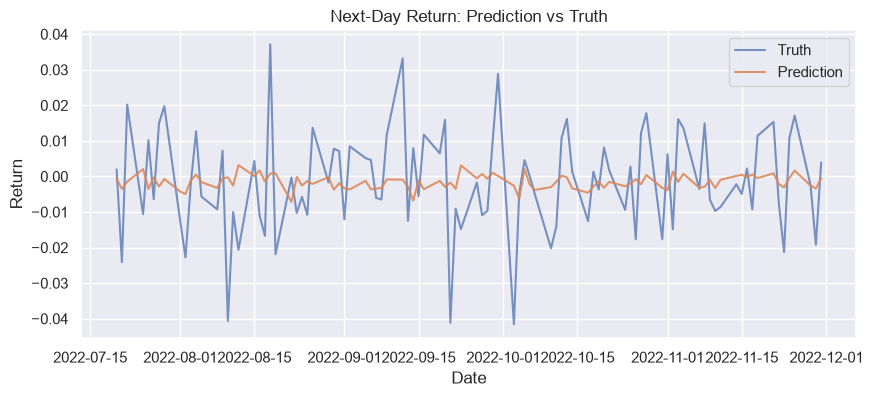

In [7]:
# Track 1: Forecasting returns
reg = Pipeline([
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression()),
])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
mae_reg = mean_absolute_error(y_te_reg, pred)
rmse_reg = mean_squared_error(y_te_reg, pred) ** 0.5
print('MAE:', mae_reg)
print('RMSE:', rmse_reg)

plt.figure(figsize=(10, 4))
plt.plot(y_te_reg.index, y_te_reg, label='Truth', alpha=0.75)
plt.plot(y_te_reg.index, pred, label='Prediction', alpha=0.85)
plt.title('Next-Day Return: Prediction vs Truth')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.show()


              precision    recall  f1-score   support

           0       0.57      0.81      0.67        53
           1       0.52      0.26      0.34        43

    accuracy                           0.56        96
   macro avg       0.55      0.53      0.51        96
weighted avg       0.55      0.56      0.52        96



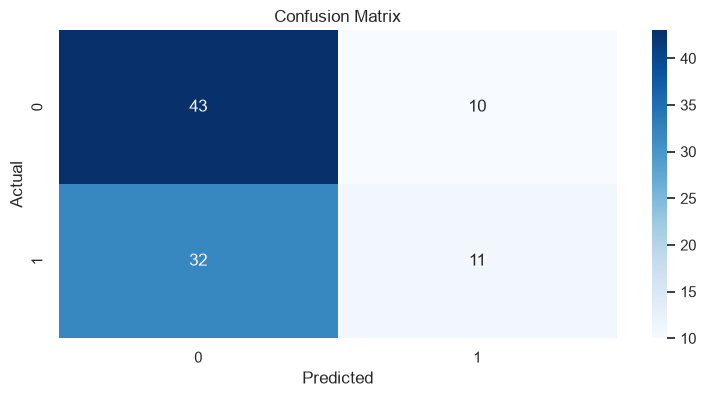

In [8]:
# Track 2: Classification (up/down)
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=1000)),
])
clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)
print(classification_report(y_te_clf, predc, zero_division=0))
cm = confusion_matrix(y_te_clf, predc)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Interpretation

The lagged return, five-day rolling mean, and twenty-day rolling volatility are calculated with a one-period shift, so they contain no information from the day being predicted. A chronological 80/20 split preserves ordering and avoids training on future observations.

The synthetic process is dominated by noise, regime changes, and occasional jumps, so the linear return forecast is expected to remain close to zero and miss many extreme days. The classification model may also perform near chance because recent returns do not strongly determine the next direction. These results are still a valid baseline: they show that correct pipeline design does not guarantee economic predictability.

The main risks are regime change, rare jumps, overlapping rolling windows, and class imbalance. I would next compare against a zero-return forecast and majority-class classifier, add momentum and longer volatility windows, and evaluate with walk-forward cross-validation rather than relying on one holdout period.


### Save Notebook
Remember to save as `homework10b_modeling-time-series-and-classification_submission.ipynb`.